### Imports + Data Loading

In [2]:
# Modules:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold

import joblib
import pickle
import os

#Data:
X_train, y_train, X_val, y_val, X_test, y_test = None, None, None, None, None, None
# with open("Data/Transformed/split.pkl", "rb") as file:
with open("Data/Transformed_OutlierAdjusted/split.pkl", "rb") as file:
    data_dict = pickle.load(file)
    X_train = data_dict["X_train"]
    y_train = data_dict["y_train"]
    X_val = data_dict["X_val"]
    y_val = data_dict["y_val"]
    X_test = data_dict["X_test"]
    y_test = data_dict["y_test"]

# As I am using CV:
X_train=pd.concat([X_train, X_val])
y_train=pd.concat([y_train, y_val])
Xcolumns = X_train.columns
ycolumns = y_train.columns

### Model Selection - With Outliers

#### Random Forest

In [20]:
# Plotting Function
def plotValidationCurveRF(rfgs):
    # Create validation plot around best parameter choice by keeping all but one parameter value constant
    # Select first non-constant parameter and obtain dictionary of all other parameters
    for key, value in rfgs.best_params_.items():
        other_items = rfgs.best_params_.copy()
        other_items.pop(key)
        
        #collect indices of all other parameters which are suposed to stay constant 
        indices = []
        if (len(other_items)==0): indices = [(i, item) in enumerate(rfgs.cv_results_["params"])]
        else:
            for i, item in enumerate(rfgs.cv_results_["params"]):
                match = True
                for condition_key, condition_value in other_items.items():
                    if(item[condition_key]!=condition_value):
                        match = False
                        break
                if(match==True):indices.append((i, item))  
        
        #select relevant datapoints from train/test scores
        x_axis, train_scores, train_std, test_scores, test_std = [],[],[],[],[]
        for i, item in indices:
            x_axis.append(item[key])
            train_scores.append(-rfgs.cv_results_["mean_train_score"][i])
            train_std.append(rfgs.cv_results_["std_train_score"][i])
            test_scores.append(-rfgs.cv_results_["mean_test_score"][i])
            test_std.append(rfgs.cv_results_["std_test_score"][i])

        #plot with correct labeling
        if(len(x_axis)>1): 
            fig = plt.figure(figsize=(6,3.5))
            plt.errorbar(x=x_axis,y=train_scores, yerr= train_std, label = "Training")
            plt.errorbar(x=x_axis,y=test_scores, yerr = train_std, label = "Cross-Validation")
            plt.xlabel(key)
            plt.ylabel("MSE")
            plt.title(f"Validation Curve - Best: {rfgs.best_params_} - Score: {-rfgs.best_score_:.3f}", fontsize=10)
            plt.grid(True)
            plt.legend()
            plt.show()
    
def crossvalidateRF(grid_parameters, cv):
    n_cpus = os.cpu_count()-2

    #Model:
    rf = RandomForestRegressor(random_state=42)
    kf=KFold(n_splits=cv, shuffle = True, random_state=42)
    gs = GridSearchCV(
        estimator = rf,
        param_grid = grid_params,
        cv = kf,
        n_jobs = n_cpus,
        scoring = "neg_mean_squared_error",
        verbose = 1,
        return_train_score = True
    )    
    rfgs = gs.fit(X_train, y_train)

    # Plot Results:
    print("Best:", rfgs.best_params_, "Score: ", -rfgs.best_score_)
    plotValidationCurveRF(rfgs=rfgs)
    
    return rfgs.best_estimator_
    

##### Optimization 1
Bootstrapping is very good, depth around 5-10, the higher min_samples the less overfitting, optimal n around 15

Fitting 5 folds for each of 1188 candidates, totalling 5940 fits
Best: {'bootstrap': True, 'max_depth': 7, 'min_samples_split': 32, 'n_estimators': 25} Score:  0.7581462418139182


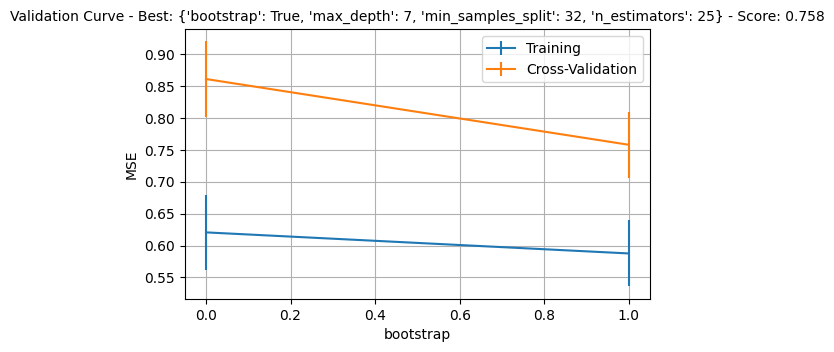

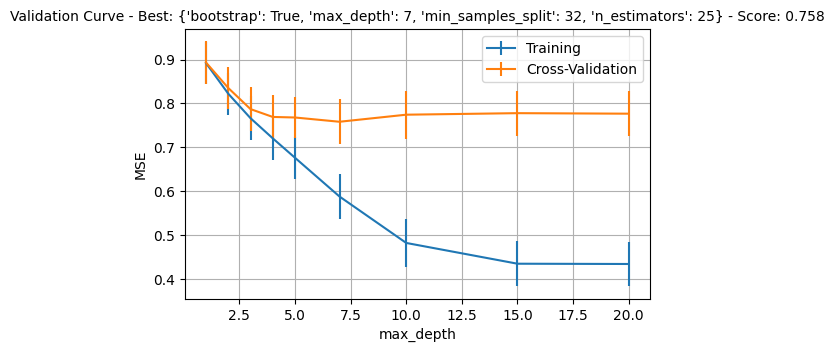

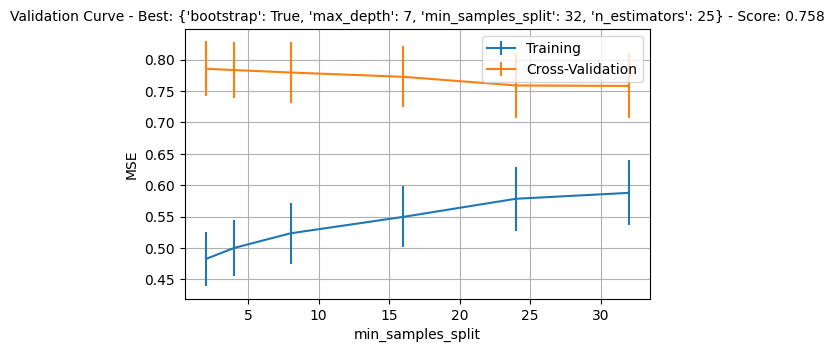

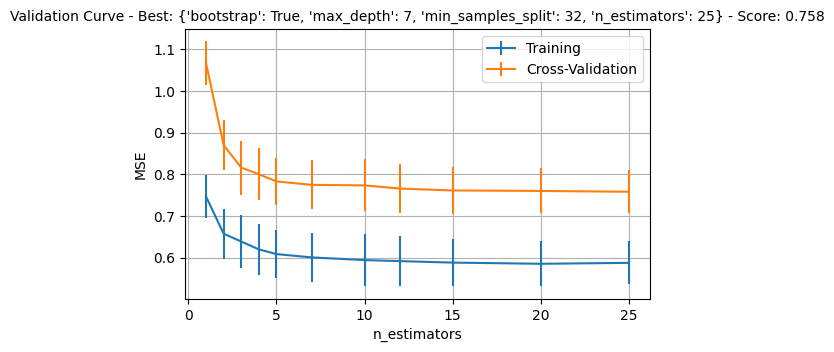

In [15]:
#Hyperparameters:
grid_params = {
    "n_estimators": [1,2,3,4,5,7,10,12,15,20,25],
    "max_depth": [1,2,3,4,5,7,10,15,20],
    "bootstrap": [True, False],
    "min_samples_split": [2,4,8,16,24,32]
}
cv=5

#Evaluate Performance
bestCV1=crossvalidateRF(grid_params, cv)

# Best Model in t=4m53s
# {'bootstrap': True, 'max_depth': 7, 'min_samples_split': 32, 'n_estimators': 25} Score:  0.7581462418139182


#### Optimization 2
min_samples around 36, max_depth 8, estimators around 20-25

Fitting 10 folds for each of 315 candidates, totalling 3150 fits
Best: {'bootstrap': True, 'max_depth': 8, 'min_samples_split': 36, 'n_estimators': 35} Score:  0.7403346368652337


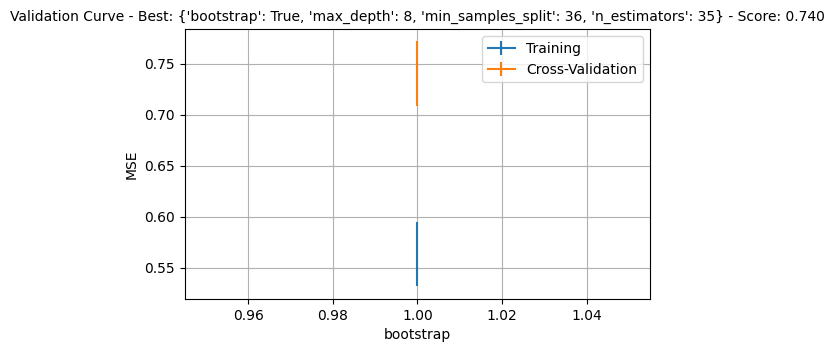

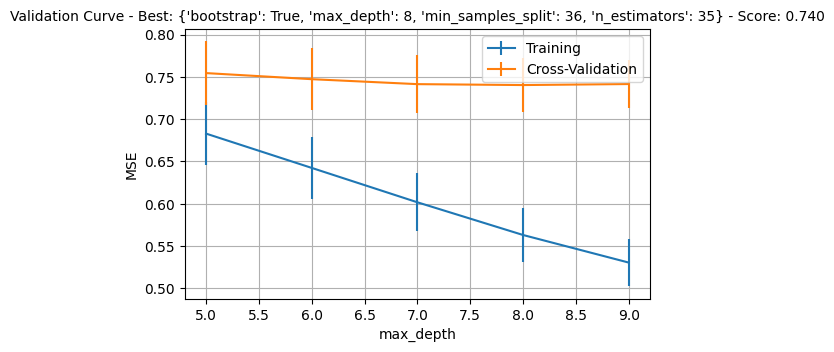

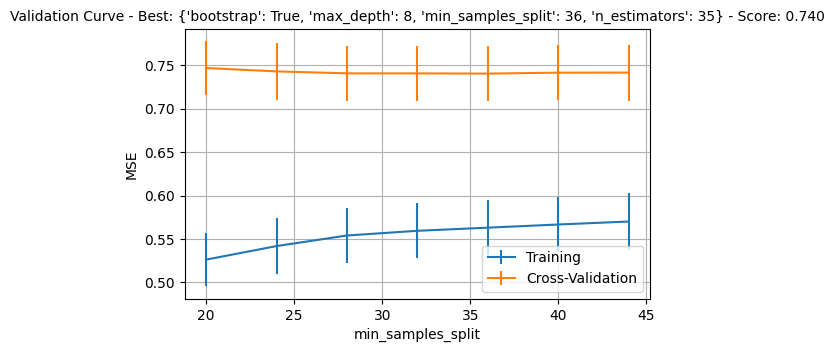

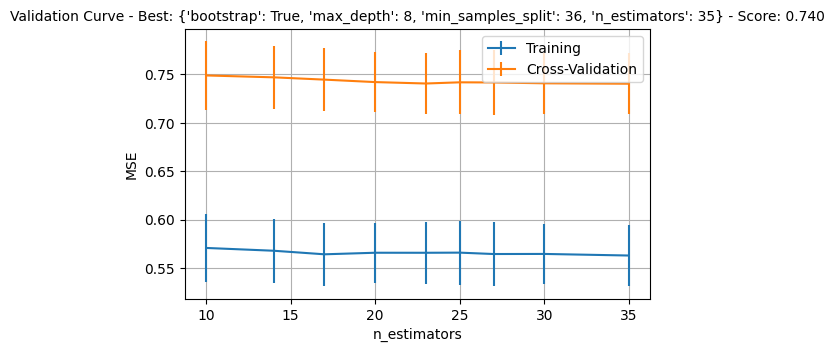

In [16]:
#Hyperparameters:
grid_params = {
    "n_estimators": [10,14,17,20,23,25,27,30,35],
    "max_depth": [5,6,7,8,9],
    "bootstrap": [True],
    "min_samples_split": [20,24,28,32,36,40,44]
}
cv=10

# Evaluate Performance
bestCV2=crossvalidateRF(grid_params, cv)

# Best Model in t = 5m38s
# {'bootstrap': True, 'max_depth': 8, 'min_samples_split': 36, 'n_estimators': 35} Score:  0.7403346368652337

#### Optimization 3


Fitting 10 folds for each of 605 candidates, totalling 6050 fits
Best: {'bootstrap': True, 'max_depth': 8, 'min_samples_split': 36, 'n_estimators': 50} Score:  0.7379852012589254


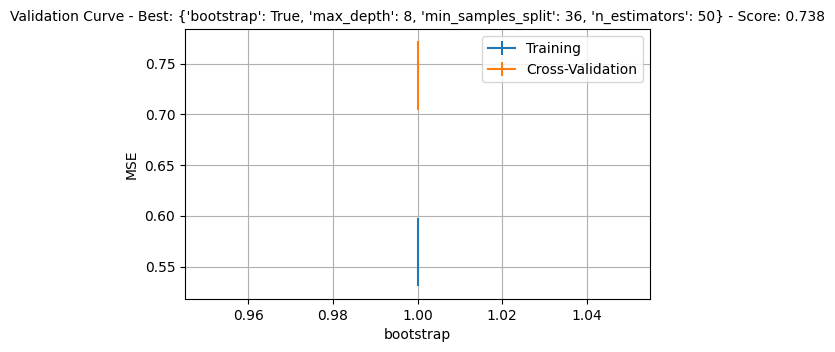

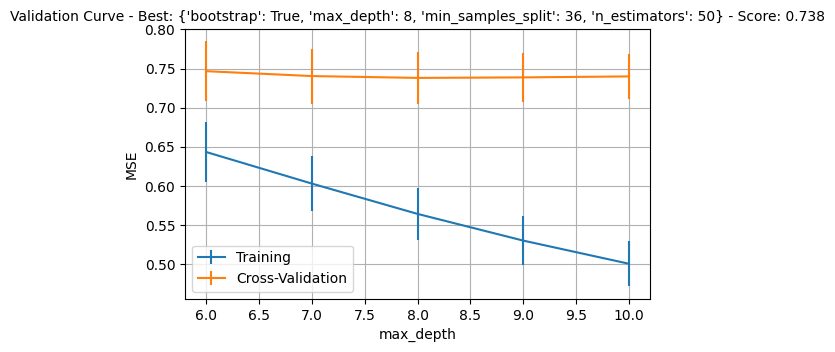

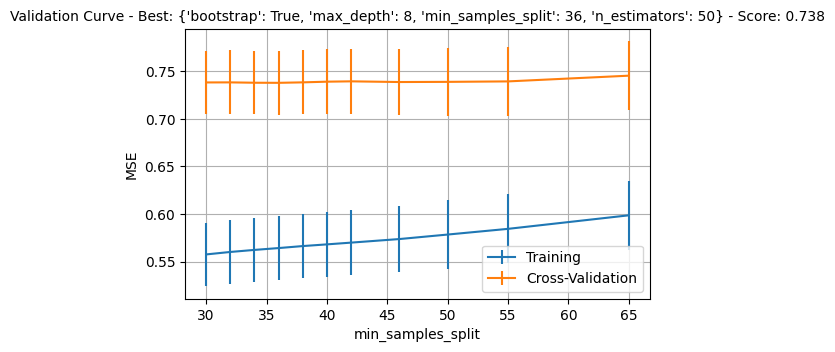

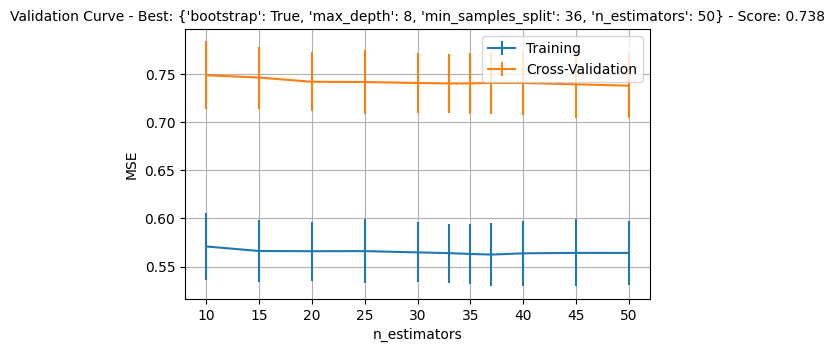

In [17]:
#Hyperparameters:
grid_params = {
    "n_estimators": [10,15,20,25,30,33,35,37,40,45,50],
    "max_depth": [6,7,8,9,10],
    "bootstrap": [True],
    "min_samples_split": [30,32,34,36,38,40,42,46,50,55,65]
}
cv=10

# Evaluate Performance
bestCV3=crossvalidateRF(grid_params, cv)

# Best Model in t=16m22s
# {'bootstrap': True, 'max_depth': 8, 'min_samples_split': 36, 'n_estimators': 50} Score:  0.7379852012589254

#### Optimization 4
No change in anything anymore (apart from miniscule one in n)

Fitting 10 folds for each of 700 candidates, totalling 7000 fits
Best: {'bootstrap': True, 'max_depth': 8, 'min_samples_split': 36, 'n_estimators': 60} Score:  0.7378235608638961


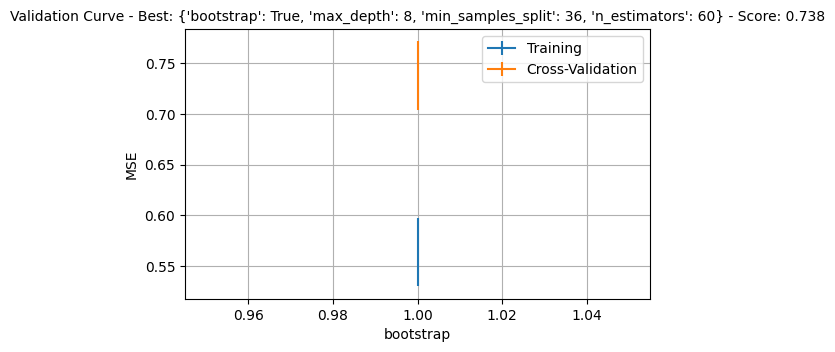

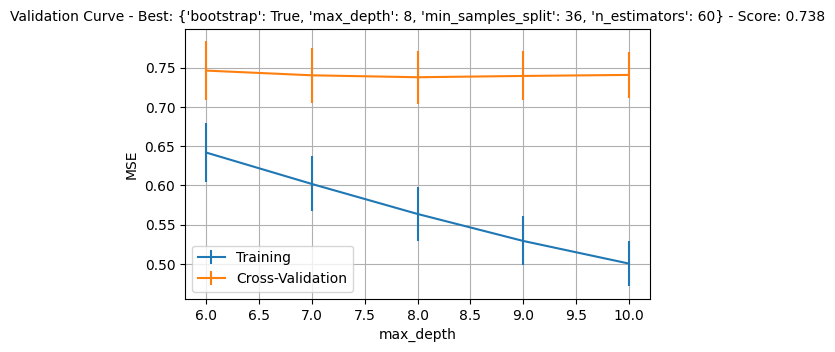

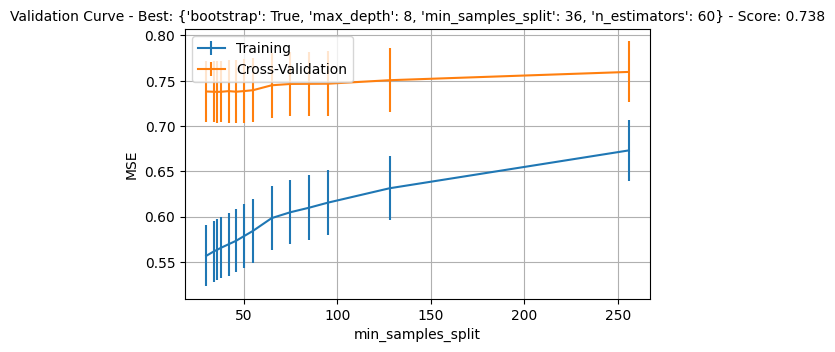

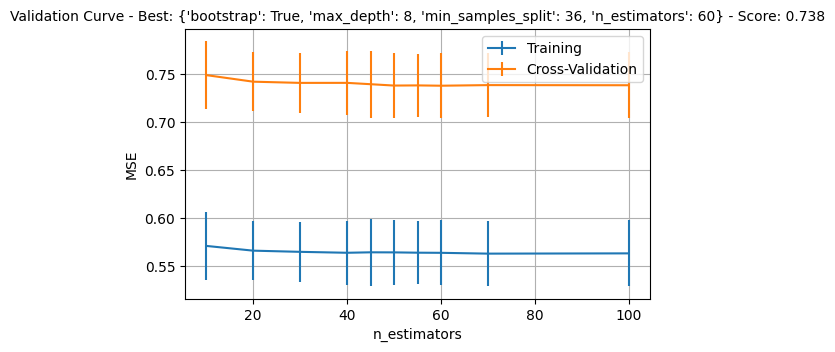

In [18]:
#Hyperparameters:
grid_params = {
    "n_estimators": [10,20,30,40,45,50,55,60,70,100],
    "max_depth": [6,7,8,9,10],
    "bootstrap": [True],
    "min_samples_split": [30,34,36,38,42,46,50,55,65,75,85,95,128,256]
}
cv=10

# Evaluate Performance
bestCV4=crossvalidateRF(grid_params, cv)

# Best Model in t=28m52s
# {'bootstrap': True, 'max_depth': 8, 'min_samples_split': 36, 'n_estimators': 60} Score:  0.7378235608638961

#### Optimization 5
Definitely no improvement after n=46

Fitting 20 folds for each of 27 candidates, totalling 540 fits
Best: {'bootstrap': True, 'max_depth': 8, 'min_samples_split': 36, 'n_estimators': 150} Score:  0.7421102907143272


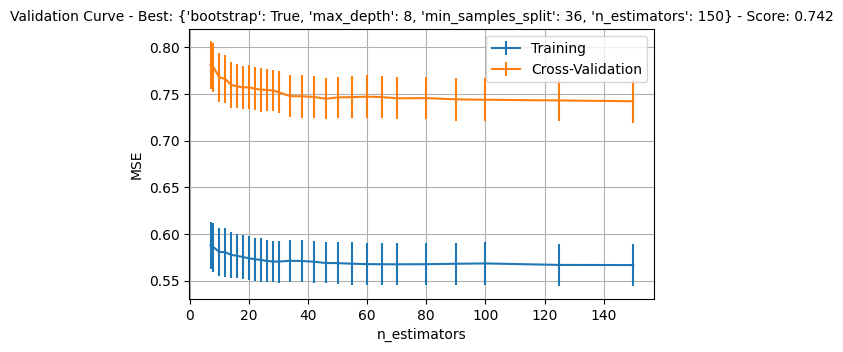

In [24]:
#Hyperparameters:
grid_params = {
    "n_estimators": [7,8,10,12,14,16,18,20,22,24,26,28,30,34,38,42,46,50,55,60,65,70,80,90,100,125,150],
    "max_depth": [8],
    "bootstrap": [True],
    "min_samples_split": [36]
}
cv=20

# Evaluate Performance
bestCV5=crossvalidateRF(grid_params, cv)

# Best Model in t=2m28s
# {'bootstrap': True, 'max_depth': 8, 'min_samples_split': 36, 'n_estimators': 150} Score:  0.7421102907143272

### Best Model Performance - With Outliers

#### Calculate Performance

In [40]:
# Parameters
n_estimators = 46
max_depth = 8
bootstrap = True
min_samples_split = 36

# Create model
best_rf = RandomForestRegressor(n_estimators = n_estimators,
                                max_depth = max_depth,
                                bootstrap = bootstrap,
                                min_samples_split = min_samples_split,
                                random_state=42
                                )

def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False)
    }

# Fit model, this time on whole training data
best_rf.fit(X=X_train, y=y_train)
best_model = best_rf

y_CV_pred = bestCV5.predict(X_test)
y_test_pred = best_rf.predict(X_test)

print("CV model: ", evaluate(y_CV_pred, y_test))
print("Best model: ", evaluate(y_test_pred, y_test))

# Final Score: 0.6270290545039963



CV model:  {'MAE': 0.24596767448729756, 'MSE': 0.6275378395297139, 'RMSE': 0.7844607009035396}
Best model:  {'MAE': 0.24496328564415987, 'MSE': 0.6270290545039963, 'RMSE': 0.7843268025637156}


In [41]:
joblib.dump(best_model, "BestModels/RandomForest.pkl")


['BestModels/RandomForest.pkl']

#### Visualize Model Performance:

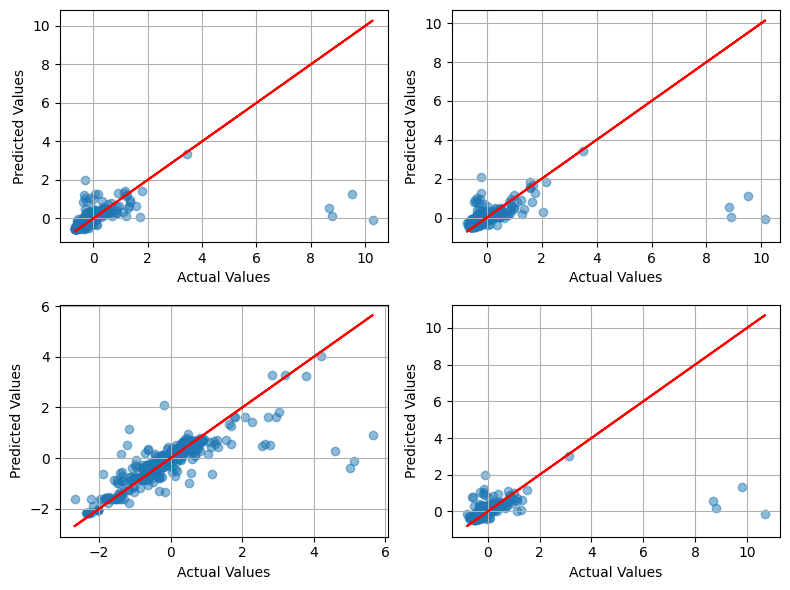

In [42]:
df_y_test_pred=pd.DataFrame(y_test_pred, columns=ycolumns)
fig, axs = plt.subplots(2, 2, figsize = (8,6))
for i, column in enumerate(y_test.columns):
    ax = axs[i // 2, i % 2]
    ax.scatter(y_test[column], df_y_test_pred[column], alpha=0.5)
    ax.plot(y_test[column],y_test[column], color="red", linestyle = "-")
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    ax.grid(True)
plt.tight_layout()
plt.show()

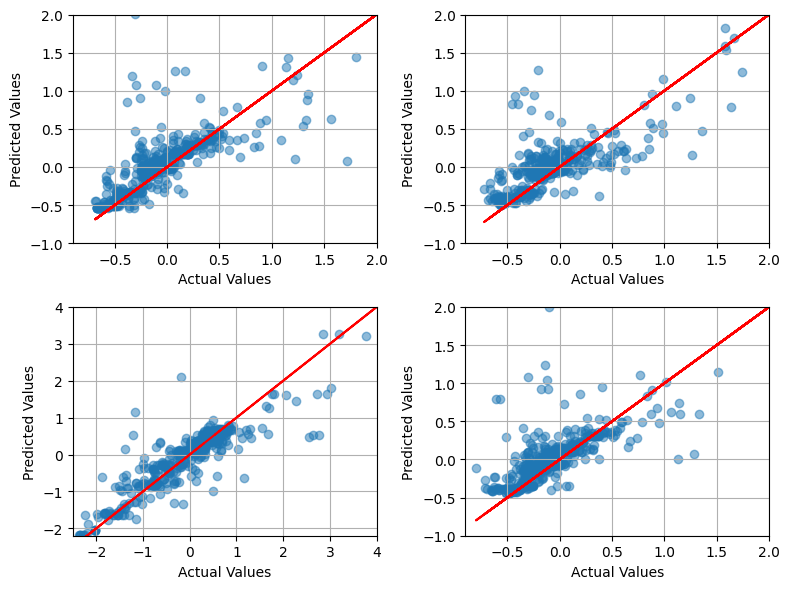

In [52]:
df_y_test_pred=pd.DataFrame(y_test_pred, columns=ycolumns)
fig, axs = plt.subplots(2, 2, figsize = (8,6))
for i, column in enumerate(y_test.columns):
    ax = axs[i // 2, i % 2]
    ax.scatter(y_test[column], df_y_test_pred[column], alpha=0.5)
    ax.plot(y_test[column],y_test[column], color="red", linestyle = "-")
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    if(i==2): 
        ax.set_xlim(-2.5,4)
        ax.set_ylim(-2.2,4)
    else: 
        ax.set_xlim(-0.9,2)
        ax.set_ylim(-1,2)
    ax.grid(True)
plt.tight_layout()
plt.show()

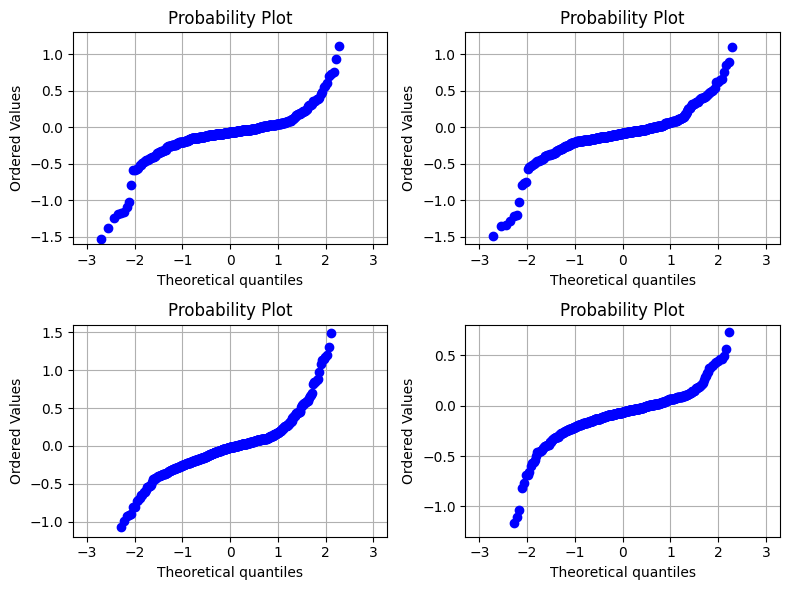

In [51]:
# Normal probability plot
y_test_error=(y_test-y_test_pred)
fig, axs = plt.subplots(2, 2, figsize = (8,6))
for i, column in enumerate(y_test.columns):
    ax = axs[i // 2, i % 2]
    _ = sp.stats.probplot(y_test_error[column], dist="norm",plot = ax, fit=False)
    if(i==2): ax.set_ylim(-1.2, 1.6)
    elif(i==3): ax.set_ylim(-1.3, 0.8)
    else: ax.set_ylim(-1.6, 1.3)
    ax.grid(True)
plt.tight_layout()
plt.show()

### Model Selection - Without Outliers

#### Random Forest

In [3]:
# Plotting Function
def plotValidationCurveRF(rfgs):
    # Create validation plot around best parameter choice by keeping all but one parameter value constant
    # Select first non-constant parameter and obtain dictionary of all other parameters
    for key, value in rfgs.best_params_.items():
        other_items = rfgs.best_params_.copy()
        other_items.pop(key)
        
        #collect indices of all other parameters which are suposed to stay constant 
        indices = []
        if (len(other_items)==0): indices = [(i, item) in enumerate(rfgs.cv_results_["params"])]
        else:
            for i, item in enumerate(rfgs.cv_results_["params"]):
                match = True
                for condition_key, condition_value in other_items.items():
                    if(item[condition_key]!=condition_value):
                        match = False
                        break
                if(match==True):indices.append((i, item))  
        
        #select relevant datapoints from train/test scores
        x_axis, train_scores, train_std, test_scores, test_std = [],[],[],[],[]
        for i, item in indices:
            x_axis.append(item[key])
            train_scores.append(-rfgs.cv_results_["mean_train_score"][i])
            train_std.append(rfgs.cv_results_["std_train_score"][i])
            test_scores.append(-rfgs.cv_results_["mean_test_score"][i])
            test_std.append(rfgs.cv_results_["std_test_score"][i])

        #plot with correct labeling
        if(len(x_axis)>1): 
            fig = plt.figure(figsize=(6,3.5))
            plt.errorbar(x=x_axis,y=train_scores, yerr= train_std, label = "Training")
            plt.errorbar(x=x_axis,y=test_scores, yerr = train_std, label = "Cross-Validation")
            plt.xlabel(key)
            plt.ylabel("MSE")
            plt.title(f"Validation Curve - Best: {rfgs.best_params_} - Score: {-rfgs.best_score_:.3f}", fontsize=10)
            plt.grid(True)
            plt.legend()
            plt.show()
    
def crossvalidateRF(grid_parameters, cv):
    n_cpus = os.cpu_count()-2

    #Model:
    rf = RandomForestRegressor(random_state=42)
    kf=KFold(n_splits=cv, shuffle = True, random_state=42)
    gs = GridSearchCV(
        estimator = rf,
        param_grid = grid_params,
        cv = kf,
        n_jobs = n_cpus,
        scoring = "neg_mean_squared_error",
        verbose = 1,
        return_train_score = True
    )    
    rfgs = gs.fit(X_train, y_train)

    # Plot Results:
    print("Best:", rfgs.best_params_, "Score: ", -rfgs.best_score_)
    plotValidationCurveRF(rfgs=rfgs)
    
    return rfgs.best_estimator_
    

##### Optimization 1
Bootstrapping is very good, depth around 10-15, the higher min_samples the less overfitting, optimal n around 15-20

Fitting 5 folds for each of 1188 candidates, totalling 5940 fits
Best: {'bootstrap': True, 'max_depth': 15, 'min_samples_split': 4, 'n_estimators': 25} Score:  0.032081033930902794


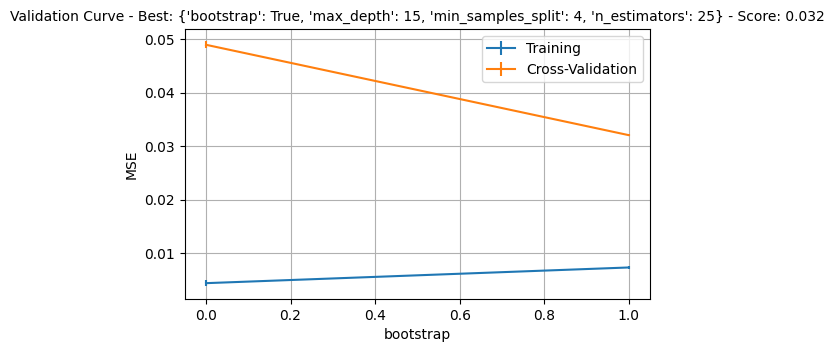

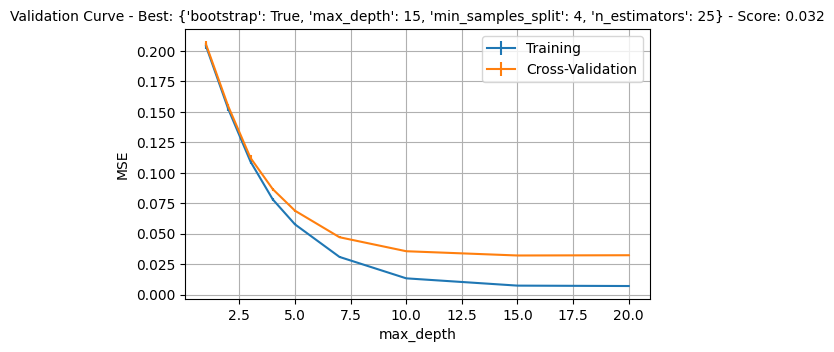

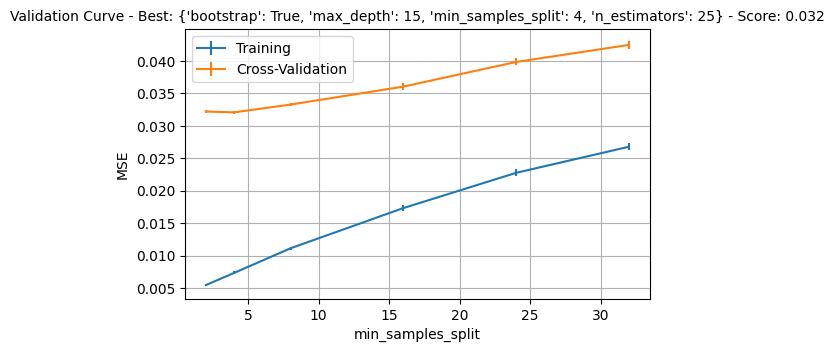

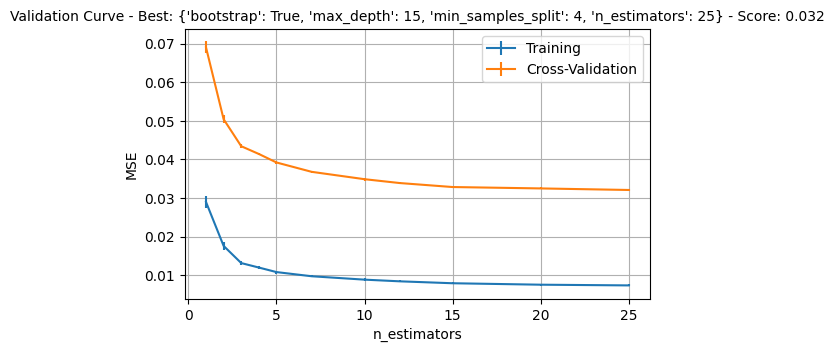

In [4]:
#Hyperparameters:
grid_params = {
    "n_estimators": [1,2,3,4,5,7,10,12,15,20,25],
    "max_depth": [1,2,3,4,5,7,10,15,20],
    "bootstrap": [True, False],
    "min_samples_split": [2,4,8,16,24,32]
}
cv=5

#Evaluate Performance
bestCV1=crossvalidateRF(grid_params, cv)

# Best Model in t=4m37s
# {'bootstrap': True, 'max_depth': 15, 'min_samples_split': 4, 'n_estimators': 25} Score:  0.032081033930902794


#### Optimization 2
min_samples 2, max_depth 16 or higher, estimators around 30

Fitting 10 folds for each of 180 candidates, totalling 1800 fits
Best: {'bootstrap': True, 'max_depth': 16, 'min_samples_split': 2, 'n_estimators': 35} Score:  0.030851284866572896


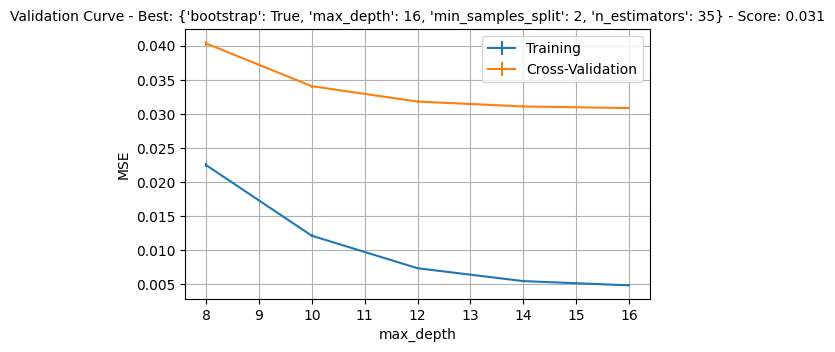

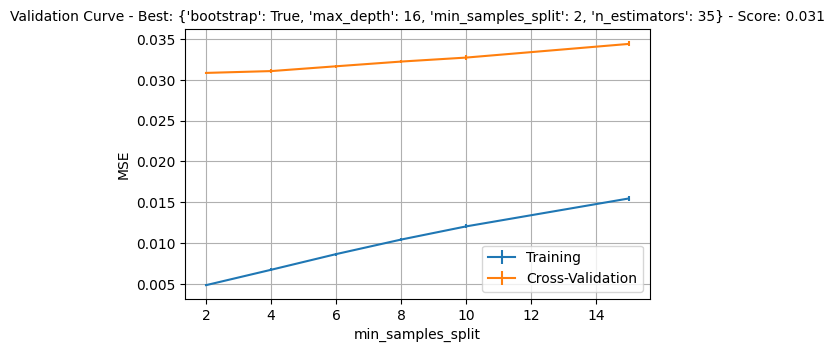

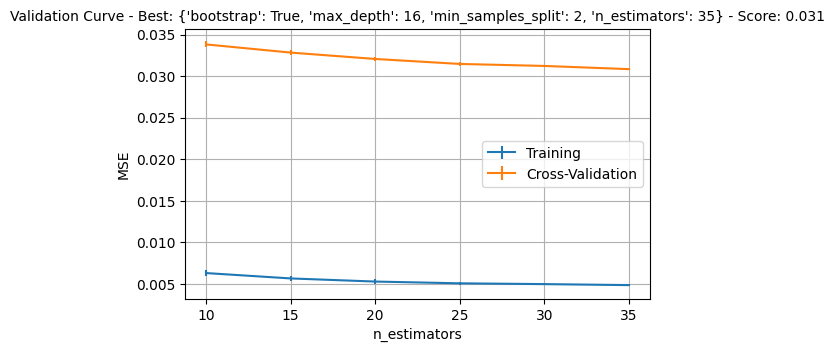

In [5]:
#Hyperparameters:
grid_params = {
    "n_estimators": [10,15,20,25,30,35],
    "max_depth": [8,10,12,14,16],
    "bootstrap": [True],
    "min_samples_split": [2,4,6,8,10,15]
}
cv=10

# Evaluate Performance
bestCV2=crossvalidateRF(grid_params, cv)

# Best Model in t = 5m2s
# {'bootstrap': True, 'max_depth': 16, 'min_samples_split': 2, 'n_estimators': 35} Score:  0.030851284866572896

#### Optimization 3


Fitting 10 folds for each of 252 candidates, totalling 2520 fits
Best: {'bootstrap': True, 'max_depth': 19, 'min_samples_split': 2, 'n_estimators': 55} Score:  0.03002982243516209


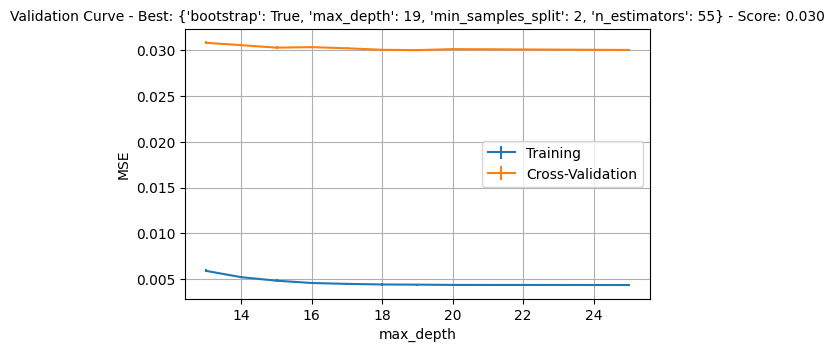

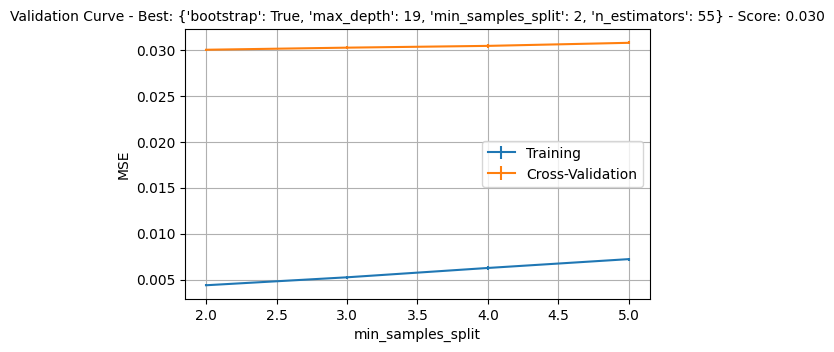

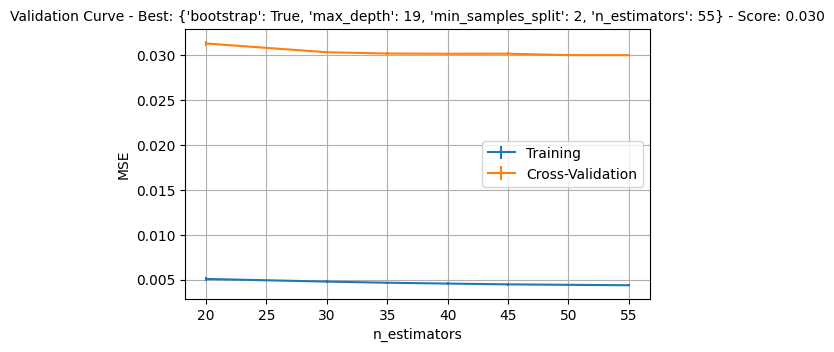

In [6]:
#Hyperparameters:
grid_params = {
    "n_estimators": [20,30,35,40,45,50,55],
    "max_depth": [13,14,15,16,17,18,19,20,25],
    "bootstrap": [True],
    "min_samples_split": [2,3,4,5]
}
cv=10

# Evaluate Performance
bestCV3=crossvalidateRF(grid_params, cv)

# Best Model in t=15m18s
# {'bootstrap': True, 'max_depth': 19, 'min_samples_split': 2, 'n_estimators': 55} Score:  0.03002982243516209

### Best Model Performance - Without Outliers

#### Calculate Performance

In [10]:
# Parameters
n_estimators = 55
max_depth = 19
bootstrap = True
min_samples_split = 2

# Create model
best_rf = RandomForestRegressor(n_estimators = n_estimators,
                                max_depth = max_depth,
                                bootstrap = bootstrap,
                                min_samples_split = min_samples_split,
                                random_state=42
                                )

def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False)
    }

# Fit model, this time on whole training data
best_rf.fit(X=X_train, y=y_train)
best_model = best_rf

y_test_pred = best_rf.predict(X_test)
print("Best model: ", evaluate(y_test_pred, y_test))

# Final Score: 0.03339337312093208


Best model:  {'MAE': 0.06918375896683711, 'MSE': 0.03339337312093208, 'RMSE': 0.16270455244647541}


In [11]:
joblib.dump(best_model, "BestModels/RandomForest.pkl")


['BestModels/RandomForest.pkl']

#### Visualize Model Performance:

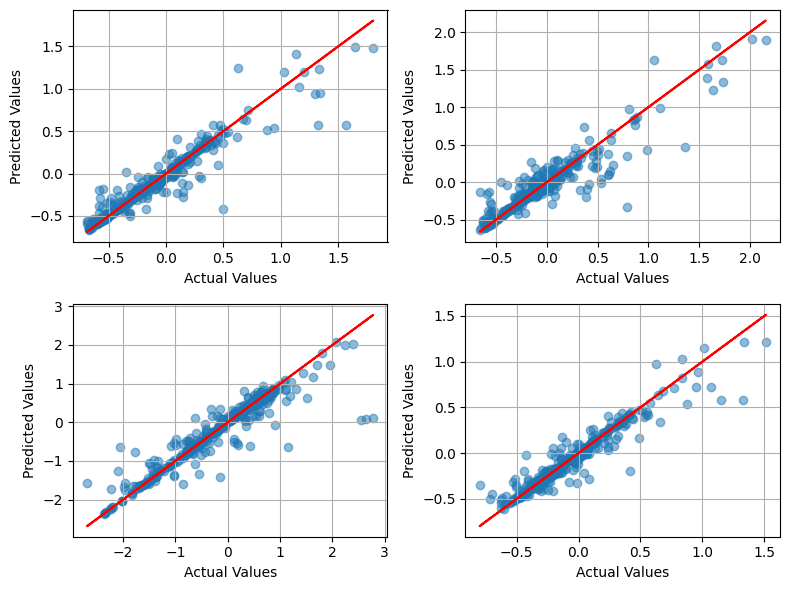

In [12]:
df_y_test_pred=pd.DataFrame(y_test_pred, columns=ycolumns)
fig, axs = plt.subplots(2, 2, figsize = (8,6))
for i, column in enumerate(y_test.columns):
    ax = axs[i // 2, i % 2]
    ax.scatter(y_test[column], df_y_test_pred[column], alpha=0.5)
    ax.plot(y_test[column],y_test[column], color="red", linestyle = "-")
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    ax.grid(True)
plt.tight_layout()
plt.show()

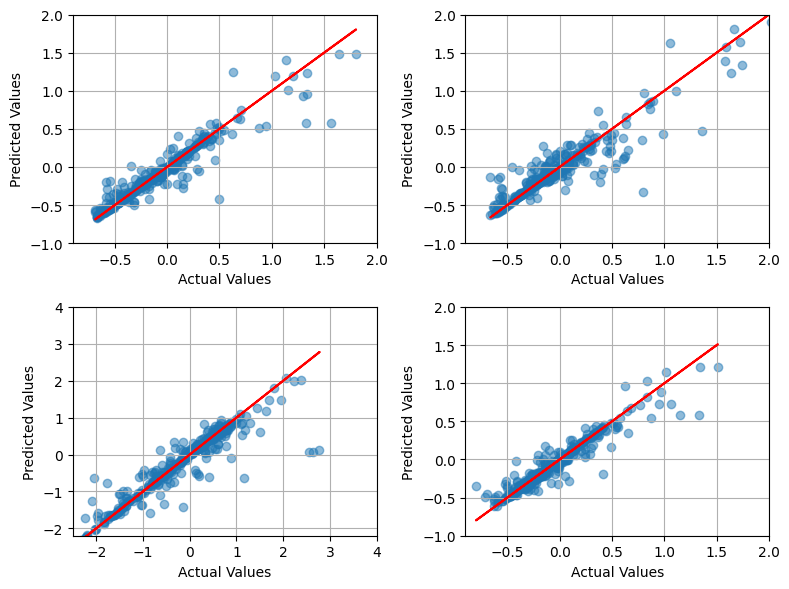

In [13]:
df_y_test_pred=pd.DataFrame(y_test_pred, columns=ycolumns)
fig, axs = plt.subplots(2, 2, figsize = (8,6))
for i, column in enumerate(y_test.columns):
    ax = axs[i // 2, i % 2]
    ax.scatter(y_test[column], df_y_test_pred[column], alpha=0.5)
    ax.plot(y_test[column],y_test[column], color="red", linestyle = "-")
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    if(i==2): 
        ax.set_xlim(-2.5,4)
        ax.set_ylim(-2.2,4)
    else: 
        ax.set_xlim(-0.9,2)
        ax.set_ylim(-1,2)
    ax.grid(True)
plt.tight_layout()
plt.show()

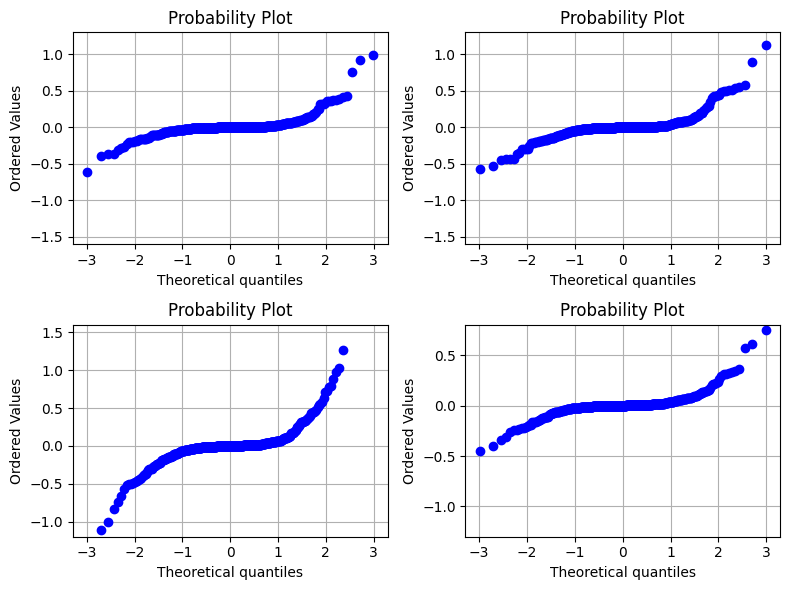

In [14]:
# Normal probability plot
y_test_error=(y_test-y_test_pred)
fig, axs = plt.subplots(2, 2, figsize = (8,6))
for i, column in enumerate(y_test.columns):
    ax = axs[i // 2, i % 2]
    _ = sp.stats.probplot(y_test_error[column], dist="norm",plot = ax, fit=False)
    if(i==2): ax.set_ylim(-1.2, 1.6)
    elif(i==3): ax.set_ylim(-1.3, 0.8)
    else: ax.set_ylim(-1.6, 1.3)
    ax.grid(True)
plt.tight_layout()
plt.show()